In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


In [2]:
# Cargar matriz de expresión
expr = pd.read_csv('expresion_filtrada.csv', index_col=0)

# Cargar metadata
meta = pd.read_csv('metadata_clinica.csv')

# Extraer etiqueta de recaída ósea
meta['bone_relapse'] = meta['characteristics_ch1'].str.extract(
    r'bone relapses \(1=yes, 0=no\): (\d)'
).astype(float)

print('Archivos cargados')
print(f'Genes:     {expr.shape[0]:,}')
print(f'Muestras:  {expr.shape[1]}')
print(f'Metadata:  {len(meta)} pacientes')
print(f'Con recaída:  {int(meta["bone_relapse"].sum())}')
print(f'Sin recaída:  {int((meta["bone_relapse"]==0).sum())}')

Archivos cargados
Genes:     16,712
Muestras:  286
Metadata:  286 pacientes
Con recaída:  69
Sin recaída:  217


In [4]:
# PCA necesita pacientes en filas y genes en columnas
# expr tiene genes en filas y pacientes en columnas
# Por eso transponemos con .T
X = expr.T

# Alinear: quedarnos solo con muestras que están en ambos archivos
muestras_comunes = [s for s in X.index if s in meta['sample_id'].values]
X = X.loc[muestras_comunes]

# Alinear metadata al mismo orden
meta_al = meta.set_index('sample_id').loc[muestras_comunes].reset_index()

# Extraer etiquetas como array numpy
etiquetas = meta_al['bone_relapse'].values

print(f'Matriz X: {X.shape[0]} pacientes × {X.shape[1]} genes')
print(f'Etiquetas: {len(etiquetas)} valores')
print(f'Con recaída (1): {int(etiquetas.sum())}')
print(f'Sin recaída (0): {int((etiquetas==0).sum())}')
print()
print('Primeras 3 muestras y sus etiquetas:')
for i in range(3):
    print(f'  {muestras_comunes[i]}: {"con recaída" if etiquetas[i]==1 else "sin recaída"}')

Matriz X: 286 pacientes × 16712 genes
Etiquetas: 286 valores
Con recaída (1): 69
Sin recaída (0): 217

Primeras 3 muestras y sus etiquetas:
  GSM36777: sin recaída
  GSM36778: sin recaída
  GSM36779: sin recaída


In [5]:
# StandardScaler pone cada gen con media=0 y std=1
# Sin esto, genes con valores altos dominarían el PCA
# injustamente — no por ser más importantes sino por
# tener números más grandes

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Datos estandarizados')
print(f'Media tras escalado:  {X_scaled.mean():.8f}  (debe ser ~0)')
print(f'Std tras escalado:    {X_scaled.std():.8f}  (debe ser ~1)')
print(f'Dimensiones:          {X_scaled.shape}')

Datos estandarizados
Media tras escalado:  0.00000000  (debe ser ~0)
Std tras escalado:    1.00000000  (debe ser ~1)
Dimensiones:          (286, 16712)


In [6]:
# n_components=50: calculamos 50 componentes
# Usaremos los primeros 2 para visualizar
# y los primeros 10 para clustering
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada por cada componente
varianza = pca.explained_variance_ratio_
varianza_acum = np.cumsum(varianza)

print('=== Varianza explicada por componente ===')
for i in range(10):
    print(f'PC{i+1:2d}: {varianza[i]*100:5.2f}%  (acumulada: {varianza_acum[i]*100:5.2f}%)')

print()
print(f'PC1+PC2 explican: {varianza_acum[1]*100:.2f}% de la varianza total')
print(f'PC1-PC10 explican: {varianza_acum[9]*100:.2f}% de la varianza total')
print()
print(f'Dimensiones X_pca: {X_pca.shape}')
print('(286 pacientes × 50 componentes)')

=== Varianza explicada por componente ===
PC 1:  7.14%  (acumulada:  7.14%)
PC 2:  5.40%  (acumulada: 12.53%)
PC 3:  5.19%  (acumulada: 17.72%)
PC 4:  3.83%  (acumulada: 21.54%)
PC 5:  2.24%  (acumulada: 23.78%)
PC 6:  1.91%  (acumulada: 25.69%)
PC 7:  1.58%  (acumulada: 27.27%)
PC 8:  1.31%  (acumulada: 28.59%)
PC 9:  1.23%  (acumulada: 29.82%)
PC10:  1.13%  (acumulada: 30.94%)

PC1+PC2 explican: 12.53% de la varianza total
PC1-PC10 explican: 30.94% de la varianza total

Dimensiones X_pca: (286, 50)
(286 pacientes × 50 componentes)


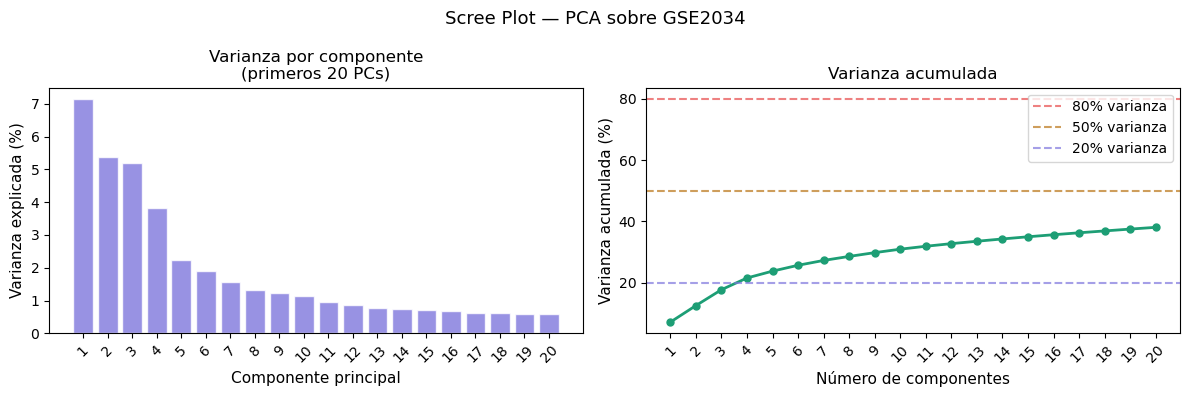

Guardado: pca_varianza.png


In [7]:
# El scree plot muestra cuánta información captura cada componente
# Es la gráfica estándar para decidir cuántos PCs usar

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Izquierda: varianza por componente (barras)
axes[0].bar(range(1, 21), varianza[:20]*100,
            color='#7F77DD', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Componente principal', fontsize=11)
axes[0].set_ylabel('Varianza explicada (%)', fontsize=11)
axes[0].set_title('Varianza por componente\n(primeros 20 PCs)')
axes[0].set_xticks(range(1, 21))
axes[0].tick_params(axis='x', rotation=45)

# Derecha: varianza acumulada (línea)
axes[1].plot(range(1, 21), varianza_acum[:20]*100,
             color='#1D9E75', linewidth=2, marker='o', markersize=5)
axes[1].axhline(80, color='#E84C4C', linestyle='--',
                alpha=0.7, label='80% varianza')
axes[1].axhline(50, color='#BA7517', linestyle='--',
                alpha=0.7, label='50% varianza')
axes[1].axhline(20, color='#7F77DD', linestyle='--',
                alpha=0.7, label='20% varianza')
axes[1].set_xlabel('Número de componentes', fontsize=11)
axes[1].set_ylabel('Varianza acumulada (%)', fontsize=11)
axes[1].set_title('Varianza acumulada')
axes[1].legend()
axes[1].set_xticks(range(1, 21))
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Scree Plot — PCA sobre GSE2034', fontsize=13)
plt.tight_layout()
plt.savefig('pca_varianza.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: pca_varianza.png')

DEGs disponibles en la matriz: 35 de 35


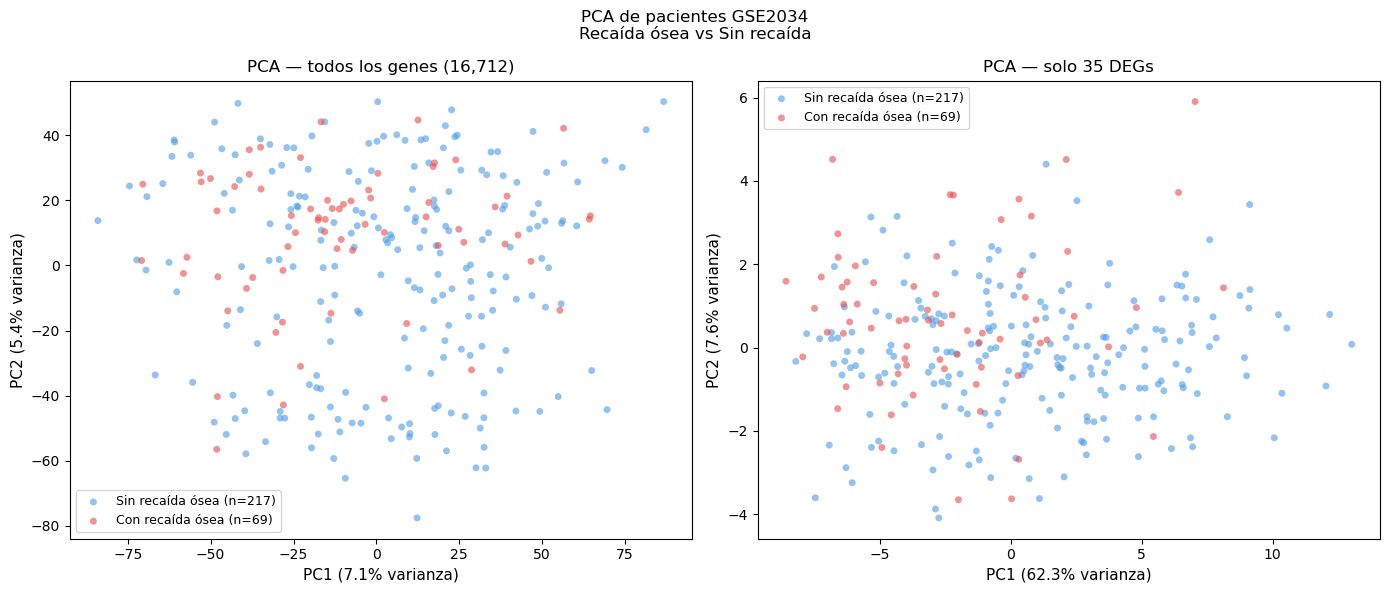

Guardado: pca_pacientes.png


In [8]:
# Aquí es donde ves si los pacientes se separan
# según su perfil genómico

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colores = {1.0: '#E84C4C', 0.0: '#4C9BE8'}
labels_t = {1.0: f'Con recaída ósea (n={int(etiquetas.sum())})',
            0.0: f'Sin recaída ósea (n={int((etiquetas==0).sum())})'}

# --- Gráfica izquierda: PCA con todos los genes ---
for grupo in [0.0, 1.0]:
    mask = etiquetas == grupo
    axes[0].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=colores[grupo],
        label=labels_t[grupo],
        alpha=0.6, s=25, edgecolors='none'
    )

axes[0].set_xlabel(f'PC1 ({varianza[0]*100:.1f}% varianza)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({varianza[1]*100:.1f}% varianza)', fontsize=11)
axes[0].set_title('PCA — todos los genes (16,712)')
axes[0].legend(fontsize=9)

# --- Gráfica derecha: PCA solo con los 35 DEGs ---
# Cargar los DEGs que encontramos el miércoles
degs_df = pd.read_csv('DEGs_significativos.csv')
degs_list = degs_df['gen'].tolist()

# Filtrar solo los DEGs que existen en X
degs_disponibles = [g for g in degs_list if g in X.columns]
print(f'DEGs disponibles en la matriz: {len(degs_disponibles)} de {len(degs_list)}')

X_degs = X[degs_disponibles].values
X_degs_scaled = StandardScaler().fit_transform(X_degs)
pca_degs = PCA(n_components=2, random_state=42)
X_pca_degs = pca_degs.fit_transform(X_degs_scaled)

for grupo in [0.0, 1.0]:
    mask = etiquetas == grupo
    axes[1].scatter(
        X_pca_degs[mask, 0],
        X_pca_degs[mask, 1],
        c=colores[grupo],
        label=labels_t[grupo],
        alpha=0.6, s=25, edgecolors='none'
    )

axes[1].set_xlabel(f'PC1 ({pca_degs.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca_degs.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=11)
axes[1].set_title(f'PCA — solo {len(degs_disponibles)} DEGs')
axes[1].legend(fontsize=9)

plt.suptitle('PCA de pacientes GSE2034\nRecaída ósea vs Sin recaída', fontsize=12)
plt.tight_layout()
plt.savefig('pca_pacientes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: pca_pacientes.png')

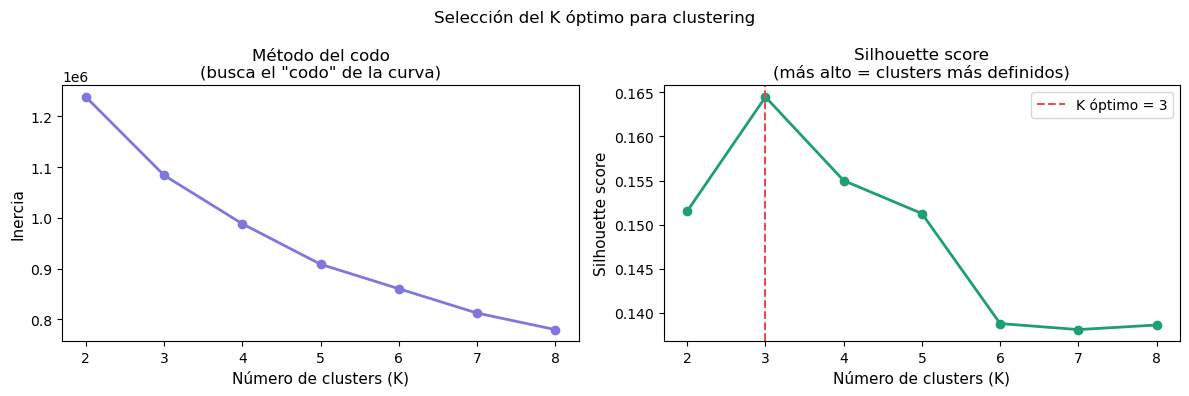

K óptimo según silhouette score: 3

Silhouette scores:
  K=2: 0.1515
  K=3: 0.1645
  K=4: 0.1550
  K=5: 0.1513
  K=6: 0.1388
  K=7: 0.1381
  K=8: 0.1386


In [9]:
# X_cl = primeros 10 componentes del PCA
# Usar 10 PCs es mejor que usar los 16,712 genes originales
# porque captura la estructura principal sin el ruido
X_cl = X_pca[:, :10]

inercias = []
silhouettes = []
ks = range(2, 9)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_cl)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cl, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Método del codo
axes[0].plot(list(ks), inercias, color='#7F77DD',
             linewidth=2, marker='o', markersize=6)
axes[0].set_xlabel('Número de clusters (K)', fontsize=11)
axes[0].set_ylabel('Inercia', fontsize=11)
axes[0].set_title('Método del codo\n(busca el "codo" de la curva)')
axes[0].set_xticks(list(ks))

# Silhouette score
axes[1].plot(list(ks), silhouettes, color='#1D9E75',
             linewidth=2, marker='o', markersize=6)
axes[1].set_xlabel('Número de clusters (K)', fontsize=11)
axes[1].set_ylabel('Silhouette score', fontsize=11)
axes[1].set_title('Silhouette score\n(más alto = clusters más definidos)')
axes[1].set_xticks(list(ks))

k_optimo = list(ks)[silhouettes.index(max(silhouettes))]
axes[1].axvline(k_optimo, color='#E84C4C', linestyle='--',
                label=f'K óptimo = {k_optimo}')
axes[1].legend()

plt.suptitle('Selección del K óptimo para clustering', fontsize=12)
plt.tight_layout()
plt.savefig('clustering_k_optimo.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'K óptimo según silhouette score: {k_optimo}')
print()
print('Silhouette scores:')
for k, s in zip(ks, silhouettes):
    print(f'  K={k}: {s:.4f}')

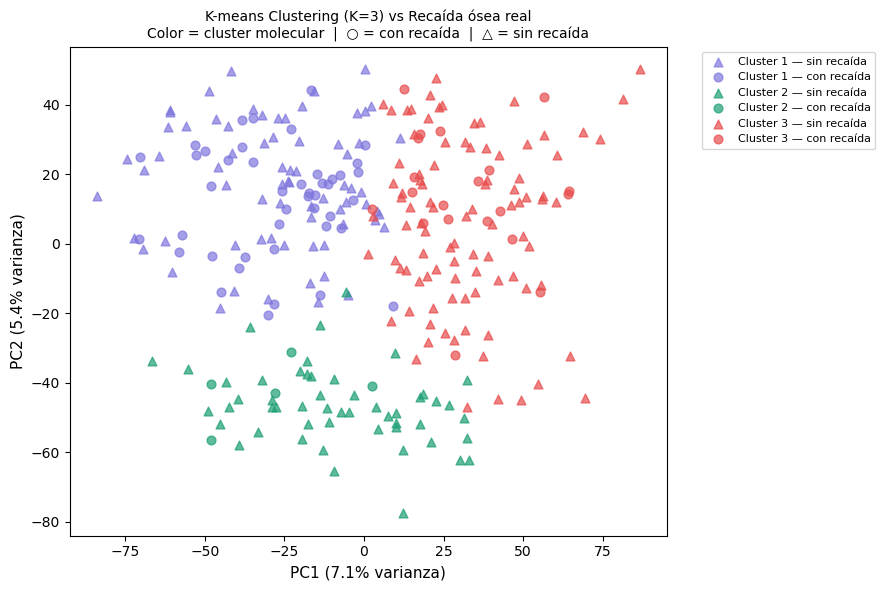

=== Comparación clusters vs etiquetas clínicas ===

Cluster 1 (115 pacientes):
  Con recaída ósea: 44 (38.3%)
  Sin recaída ósea: 71 (61.7%)

Cluster 2 (57 pacientes):
  Con recaída ósea: 5 (8.8%)
  Sin recaída ósea: 52 (91.2%)

Cluster 3 (114 pacientes):
  Con recaída ósea: 20 (17.5%)
  Sin recaída ósea: 94 (82.5%)



In [10]:
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_cl)

colores_c = {0: '#7F77DD', 1: '#1D9E75', 2: '#E84C4C'}

fig, ax = plt.subplots(figsize=(9, 6))

for c in [0, 1, 2]:
    for r in [0.0, 1.0]:
        mask = (cluster_labels == c) & (etiquetas == r)
        if mask.sum() > 0:
            ax.scatter(
                X_pca[mask, 0],
                X_pca[mask, 1],
                c=colores_c[c],
                marker='o' if r==1 else '^',
                alpha=0.7, s=40,
                label=f'Cluster {c+1} — {"con" if r==1 else "sin"} recaída'
            )

ax.set_xlabel(f'PC1 ({varianza[0]*100:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'PC2 ({varianza[1]*100:.1f}% varianza)', fontsize=11)
ax.set_title('K-means Clustering (K=3) vs Recaída ósea real\n'
             'Color = cluster molecular  |  ○ = con recaída  |  △ = sin recaída',
             fontsize=10)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('clustering_final.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Comparación clusters vs etiquetas clínicas ===')
print()
for c in [0, 1, 2]:
    mask = cluster_labels == c
    n_total = mask.sum()
    n_r = int(etiquetas[mask].sum())
    n_n = int((etiquetas[mask] == 0).sum())
    pct_r = n_r/n_total*100
    print(f'Cluster {c+1} ({n_total} pacientes):')
    print(f'  Con recaída ósea: {n_r} ({pct_r:.1f}%)')
    print(f'  Sin recaída ósea: {n_n} ({100-pct_r:.1f}%)')
    print()

In [11]:
resumen = pd.DataFrame({
    'metrica': [
        'Pacientes analizados',
        'Genes usados (PCA)',
        'Varianza PC1',
        'Varianza PC2',
        'Varianza PC1+PC2',
        'Varianza PC1-PC10',
        'K óptimo (silhouette)',
        'Silhouette score óptimo',
        'DEGs usados en PCA2'
    ],
    'valor': [
        X.shape[0],
        X.shape[1],
        f'{varianza[0]*100:.2f}%',
        f'{varianza[1]*100:.2f}%',
        f'{varianza_acum[1]*100:.2f}%',
        f'{varianza_acum[9]*100:.2f}%',
        k_optimo,
        f'{max(silhouettes):.4f}',
        len(degs_disponibles)
    ]
})

resumen.to_csv('resumen_pca_clustering.csv', index=False)
print('=== Resumen del análisis ===')
print(resumen.to_string(index=False))
print()
print('Archivos generados hoy:')
for f in ['pca_varianza.png', 'pca_pacientes.png',
          'clustering_k_optimo.png', 'clustering_final.png',
          'resumen_pca_clustering.csv']:
    import os
    existe = '✓' if os.path.exists(f) else '✗'
    print(f'  {existe} {f}')

=== Resumen del análisis ===
                metrica  valor
   Pacientes analizados    286
     Genes usados (PCA)  16712
           Varianza PC1  7.14%
           Varianza PC2  5.40%
       Varianza PC1+PC2 12.53%
      Varianza PC1-PC10 30.94%
  K óptimo (silhouette)      3
Silhouette score óptimo 0.1645
    DEGs usados en PCA2     35

Archivos generados hoy:
  ✓ pca_varianza.png
  ✓ pca_pacientes.png
  ✓ clustering_k_optimo.png
  ✓ clustering_final.png
  ✓ resumen_pca_clustering.csv
